# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☑ Standard Analysis ☐ Research-Oriented

**Group members:**  
- Vlad Vladutu 
- Daniel Langdal Jensen
- Victor Bakkestrøm Poulsen

**Dataset:**  Oracle's Elixir League of Legends esports stats https://oracleselixir.com/tools/downloads (currently 2025 only)

### The project is split in 3 big chapter tasks:
- Clustering and Outlier detection
- Graph Mining
- Pattern Mining


## Task1: Clustering and Outlier detection
- Clustering player performances
- Clustering matches
- Clustering players
- Clustering teams
- Finding outlier players
- Finding outlier teams. 

A player performance is an individual row in the dataset. It includes the statistics of one player in one single game.

A match is the composition of the 10 players participating in it, 5 in each of the teams.

A "player" is defined by it's overall performance across all games he played into. (Aggregated with mean)

A "team" is defined by the overall performance of a team across all games they played into. (Aggregated with mean)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
from sklearn.cluster import OPTICS
import matplotlib.gridspec as gridspec
cwd = Path('.')

### Load data

In [23]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
#data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\1306643242.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [24]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/10053 [00:00<?, ?it/s]

KeyboardInterrupt: 

skip running above cell by loading the full imputated data

In [25]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


Text(0.5, 1.0, 'percentage of missing values by column')

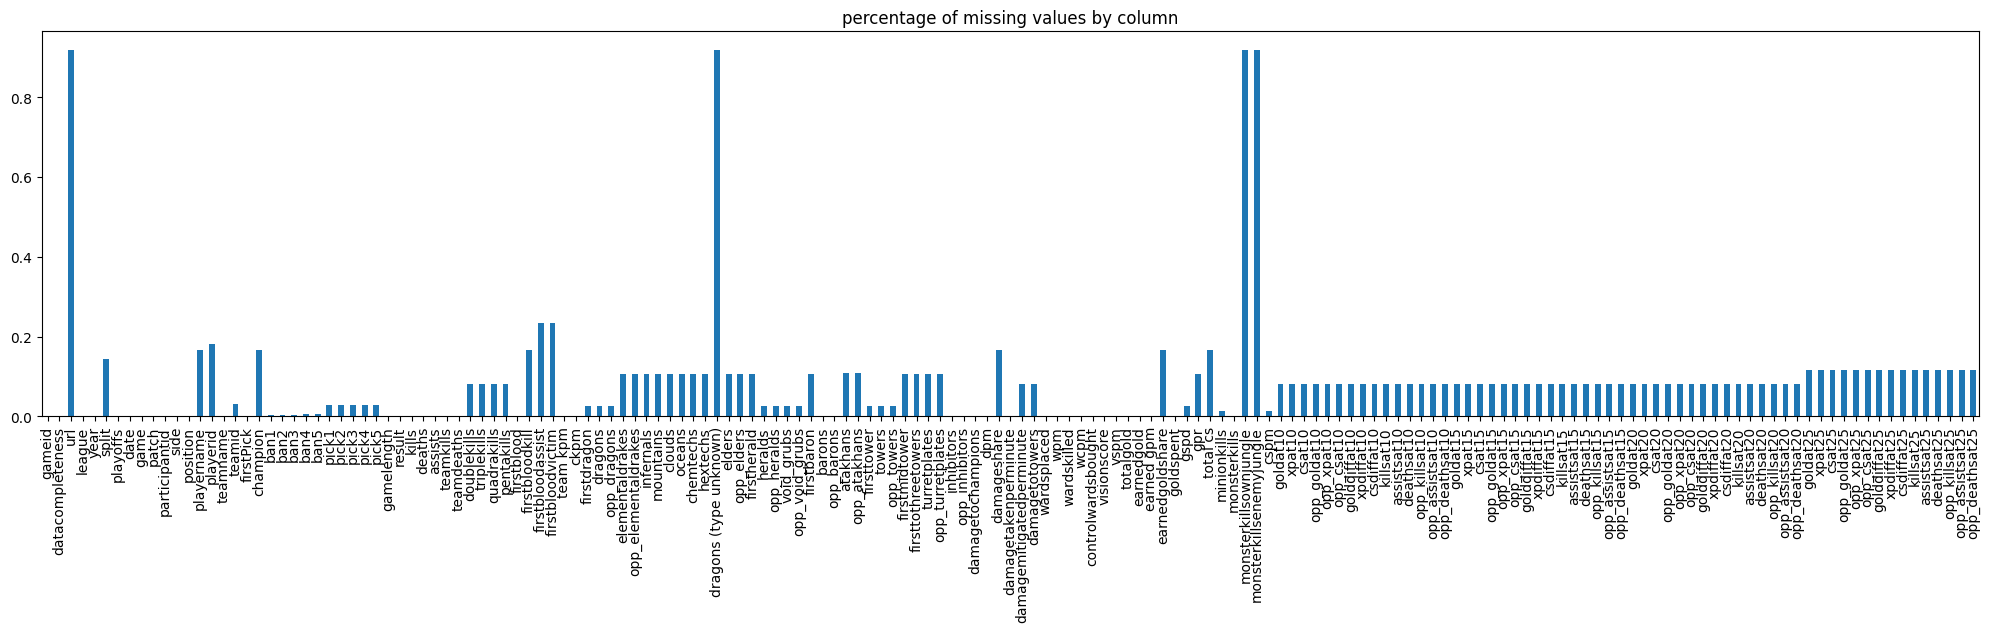

In [26]:
data.isnull().mean().plot(kind='bar', figsize=(25, 5))
plt.title('percentage of missing values by column')

In [27]:
#data.to_csv("2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv")

We then drop all rows that only contain teamwide statistics, as we are currently interested in the player performances

In [28]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

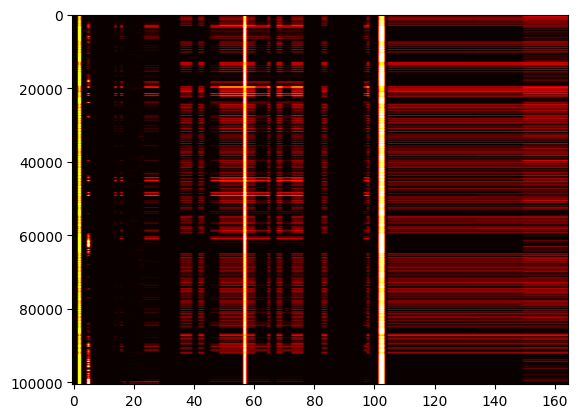

In [29]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [30]:
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [31]:
100 * len(data) / data_len

71.58062269969163

% of the data rows, which represents 

In [32]:
len(data) / 10

7196.0

matches

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [33]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "split", "side", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [34]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(71960, 1829)

This gives us a 1829-dimensional vector for each player-performance. Because of the curse of dimensionality this is too much to expect good results from, therefore we engineer a better vector by only keeping dimensions that are crucial for differentiating player performances. 

### Normalize data and calculate covariance and correlation matrix

In [35]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player performances that clusters each player performance into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [36]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

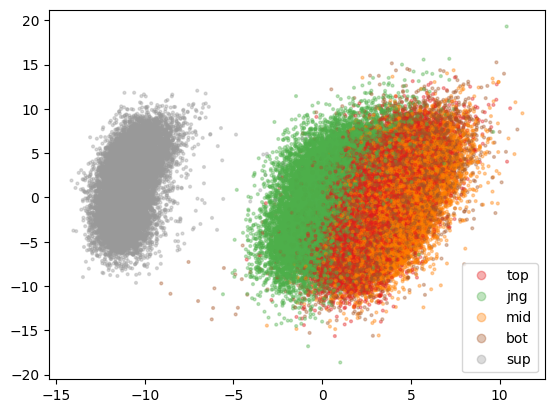

In [37]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=4, alpha=0.35)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

In [38]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("")

Cluster 0:
position
mid    300
top    285
bot    284
jng    267
sup      5
Name: count, dtype: int64

Cluster 1:
position
jng    317
bot      5
top      4
mid      4
sup      3
Name: count, dtype: int64

Cluster 2:
position
jng    7067
top    6870
mid    6529
bot    6236
sup       2
Name: count, dtype: int64

Cluster 3:
position
sup    14370
bot        2
jng        1
Name: count, dtype: int64

Cluster 4:
position
bot    7865
mid    7559
top    7233
jng    6740
sup      12
Name: count, dtype: int64



We can see that we can easily separate support from the rest, but the other clusters are mixed and don't single out specific roles. While our clustering approach isn't perfect (we can see on the PCA plot that we should probably be able to cluster jungle well currently), we can still engineer our data much better. One reason this could be happening is due to the curse of dimensionality, we have 1800 dimensions and most of them are not important for clustering the points but having them increases the difficulty of the problem due to the curse of dimensionality. Our next approach is therefore to alleviate this by reducing the amount of dimensions. 

# Reducing the amount of dimensions

We pick out columns we have manually determined to likely play a big impact in differentiating player performances. Furthermore, we reduce the picked champion column from a one-hot encoding that takes 172 dimensions to a champion tag column that takes around 10 dimensions but is not a one-hot encoding, to do this we reduce the official league of legends champion class tags, for example, the champion Alistar is tagged as "Support" and "Tank", meaning the support and tank columns will have value 1, and the other columns will have value 0.

In [39]:
most_relevant_columns = ['champion', 'kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damageshare', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
data_pure = data[most_relevant_columns + ["position"]]
from utils.transform import champion_class_transform
import importlib
import sys
importlib.reload(sys.modules["utils.transform"])
data_pure = champion_class_transform(data_pure)
data_pure[["Tank", "Fighter", "Assassin", "Mage", "Marksman", "Support"]]

,Tank,Fighter,Assassin,Mage,Marksman,Support
0,1,1,0,0,0,0
1,1,0,0,0,0,1
2,0,0,0,1,0,1
3,0,0,0,0,1,0
4,1,0,0,0,0,1
...,...,...,...,...,...,...
118925,0,1,0,0,0,0
118926,1,1,0,0,0,0
118927,0,0,1,1,0,0
118928,0,0,0,0,1,0


In [40]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
print(X.shape)

X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("")

(71960, 37)
Cluster 0:
position
mid    10281
top     1786
jng      361
bot      219
sup        3
Name: count, dtype: int64

Cluster 1:
position
sup    14375
bot       19
jng        7
top        2
mid        1
Name: count, dtype: int64

Cluster 2:
position
top    11919
mid     1708
bot       37
sup        8
jng        7
Name: count, dtype: int64

Cluster 3:
position
bot    14112
mid     2396
top      636
jng       35
sup        4
Name: count, dtype: int64

Cluster 4:
position
jng    13982
top       49
mid        6
bot        5
sup        2
Name: count, dtype: int64



Our clustering is much better now, and succeeds in separating the data into 5 clusters based on roles, with a little abiguity in top/mid/bot. We also do a PCA plot to visualize the clusters around roles: 

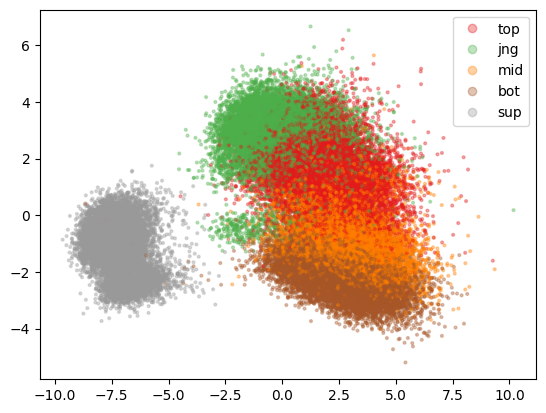

In [41]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=4, alpha=0.35)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

We can also do a T-sne plot, to see if our data can be better nonlinearly separated

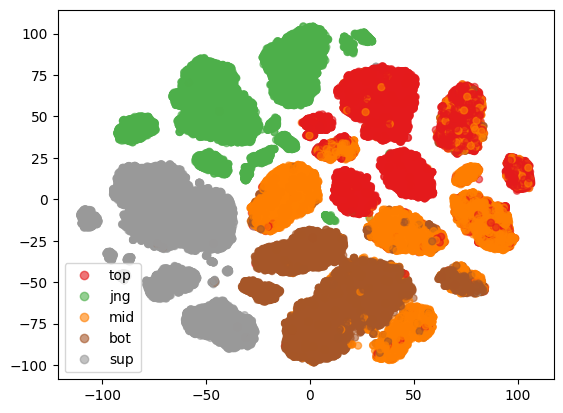

In [42]:
X_embedded = sklearn.manifold.TSNE(n_components=2, verbose=0).fit_transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

# Clustering of unknown quantity

## Clustering similar players

In order to cluster similar players we will take all of a players match performances and aggregate them into a single row by taing the mean, this aggregation will then represent that player.

In [43]:
data_pure = data[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)


player_data = []
for player in tqdm(data["playerid"].unique()):
    player_indexes = data.loc[data["playerid"] == player].index

    player_data.append([player] + data_numeric.loc[player_indexes].mean().tolist())

player_data = pd.DataFrame(player_data, columns=["playerid"] + list(data_numeric.columns))
player_data

  0%|          | 0/2118 [00:00<?, ?it/s]

,playerid,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,...,Support,Tank,Assassin,Marksman,Mage,position_bot,position_jng,position_mid,position_sup,position_top
0,oe:player:c659697694306de62d978569b84c344,3.032787,3.229508,6.573770,17642.983607,534.275141,0.199160,920.276048,1245.953148,3907.918033,...,0.032787,0.672131,0.081967,0.000000,0.311475,0.0,0.0,0.0,0.0,1.0
1,oe:player:dbdc61a1c41acedcbc7d399727155ac,3.440000,3.320000,8.880000,14966.580000,446.737598,0.170040,1123.416300,961.468164,1897.240000,...,0.360000,0.640000,0.160000,0.060000,0.140000,0.0,1.0,0.0,0.0,0.0
2,oe:player:694d028e62f4ea668b206ab752b6f94,4.901639,2.786885,7.508197,26986.622951,797.252087,0.295961,599.457866,434.158987,5073.590164,...,0.393443,0.000000,0.278689,0.163934,0.885246,0.0,0.0,1.0,0.0,0.0
3,oe:player:90704735ca9fc01f2244f23f6e5d635,5.548387,3.080645,6.274194,27119.467742,798.326889,0.284142,567.370126,376.748306,4971.629032,...,0.016129,0.000000,0.016129,1.000000,0.596774,1.0,0.0,0.0,0.0,0.0
4,oe:player:74f3f60a44ee916ecc257a5381be756,0.770492,3.901639,11.770492,6474.885246,193.323680,0.072830,646.139526,754.646284,1316.950820,...,0.983607,0.737705,0.000000,0.000000,0.131148,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2113,oe:player:c142a73b77f3c3df40777af2651f491,3.045455,4.409091,6.727273,18375.818182,614.637000,0.172104,1170.308259,1282.487986,3310.772727,...,0.000000,0.727273,0.136364,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0
2114,oe:player:ada61b4241a68d672021ea46ab8bbf3,0.833333,3.750000,12.166667,6803.354167,222.529965,0.070088,581.836025,552.818027,442.750000,...,1.000000,0.708333,0.000000,0.000000,0.187500,0.0,0.0,0.0,1.0,0.0
2115,oe:player:768e1142ef81d6be29d5c000543bc28,3.200000,5.200000,5.400000,22980.400000,701.448720,0.220709,1049.988460,988.780800,6942.000000,...,0.000000,0.200000,0.200000,0.000000,0.200000,0.0,0.0,0.0,0.0,1.0
2116,oe:player:59d2a5ca2edb7a94fcf37170219e2c0,3.800000,4.200000,6.200000,14499.600000,440.315120,0.134900,1169.656360,1021.162460,1831.200000,...,0.000000,0.200000,0.800000,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0


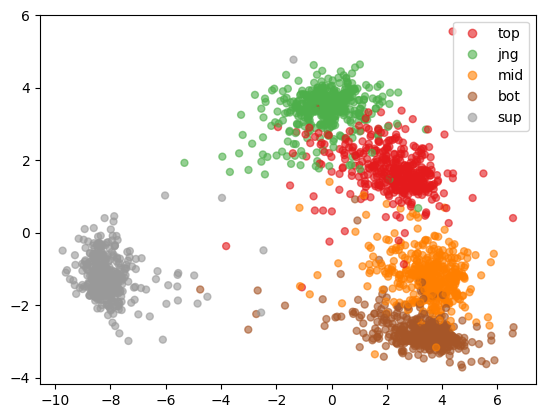

In [44]:
X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

aligned_columns = player_data.columns[1:]
position_indexes = np.where(("position_top" == aligned_columns) | ("position_jng" == aligned_columns) | ("position_mid" == aligned_columns) | ("position_bot" == aligned_columns) | ("position_sup" == aligned_columns))

X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"position_top": 0, "position_jng": 1, "position_mid": 2, "position_bot": 3, "position_sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=player_data[["position_top", "position_jng", "position_mid", "position_bot", "position_sup"]].idxmax(axis=1).map(z), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

This approach gives us pretty well separable clusters of players by role. But by taking the mean we have losta great deal of information about the distribution of that players performances, so in order to recover this information and thus get more separable data we will add extra columns with information about the distributions of the columns for the player, such as variance and q-quantiles. 

In [45]:
from utils.transform import aggregate_stats

In [46]:
data_pure = data[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)
data_numeric_with_id = data_numeric.copy()
data_numeric_with_id["playerid"] = data["playerid"]

player_data = aggregate_stats(data_numeric_with_id, id_col="playerid")
player_data

,playerid,kills_mean,deaths_mean,assists_mean,damagetochampions_mean,dpm_mean,damageshare_mean,damagetakenperminute_mean,damagemitigatedperminute_mean,damagetotowers_mean,...,position_jng_q75,position_mid_q25,position_mid_q50,position_mid_q75,position_sup_q25,position_sup_q50,position_sup_q75,position_top_q25,position_top_q50,position_top_q75
0,oe:player:0015d99e65183977a9e65547b37f1cb,0.811321,3.584906,9.075472,6807.603774,213.932492,0.088240,575.335872,548.155623,879.226415,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
1,oe:player:004e96a525452599860ca439bf916bd,1.785714,4.214286,4.714286,13355.928571,397.235579,0.157180,1131.923243,1336.284457,1867.214286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,oe:player:00558cb3daa73e60ba4af7e7060e6e2,2.600000,4.450000,8.150000,15546.250000,501.602930,0.172804,1230.764380,1278.812660,1341.400000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,oe:player:0066010bf7c06628559f1704f5d6d39,1.666667,5.000000,2.333333,19767.666667,616.912900,0.231892,1084.512200,1397.444167,1997.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,oe:player:007be3acd5669d100711b13d79e2336,3.103448,3.241379,5.448276,18214.965517,527.202317,0.182532,832.762955,793.221162,4773.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,oe:player:ff5791b44dd8871b952a4b6e49cc764,3.407407,3.962963,7.037037,21113.666667,586.170089,0.198727,922.046993,1063.240481,3161.407407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1959,oe:player:ff804ef6d4438e1428e8eb2a8320deb,1.750000,5.750000,2.500000,25235.750000,742.443325,0.286384,1619.908900,1199.707750,5198.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1960,oe:player:ffa7f50db949da3f7ccec7e2c4ec4c6,4.574468,2.829787,6.680851,30400.468085,908.016030,0.301014,527.142221,372.111245,6180.106383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1961,oe:player:ffad8c412f83018566a377cc0496a3b,1.800000,3.200000,4.800000,14638.800000,436.572860,0.178378,845.213000,818.277540,2453.200000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


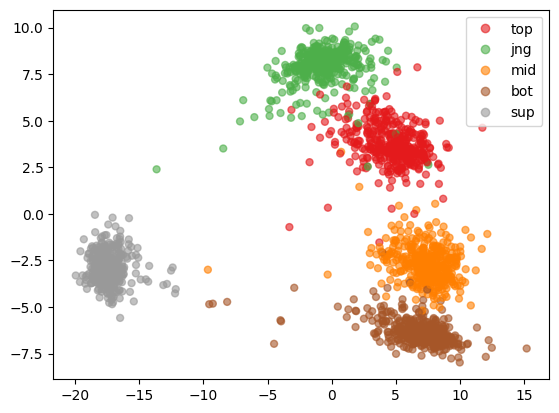

In [ ]:
X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

aligned_columns = player_data.columns[1:]
position_indexes = np.where(("position_top" == aligned_columns) | ("position_jng" == aligned_columns) | ("position_mid" == aligned_columns) | ("position_bot" == aligned_columns) | ("position_sup" == aligned_columns))
position_indexes_var = np.where(("position_top_var" == aligned_columns) | ("position_jng_var" == aligned_columns) | ("position_mid_var" == aligned_columns) | ("position_bot_var" == aligned_columns) | ("position_sup_var" == aligned_columns))

X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_hat_no_position = np.delete(X_hat, position_indexes_var, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"position_top_q75": 0, "position_jng_q75": 1, "position_mid_q75": 2, "position_bot_q75": 3, "position_sup_q75": 4} # MADE CHANGE DUE TO AGGREGATE
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=player_data[["position_top_q75", "position_jng_q75", "position_mid_q75", "position_bot_q75", "position_sup_q75"]].idxmax(axis=1).map(z), cmap="Set1", s=25, alpha=0.6)# MADE CHANGE DUE TO AGGREGATE
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

This appears to make the clusters more dense and thus will likely make them easier to separate and run our clustering algorithms on. Let's run K-means:

In [ ]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(player_data.iloc[np.where(clustering.labels_ == i)[0]][["position_top_q75", "position_jng_q75", "position_mid_q75", "position_bot_q75", "position_sup_q75"]].idxmax(axis=1).value_counts())
    print("")# MADE CHANGE DUE TO AGGREGATE

Cluster 0:
position_mid_q75    378
Name: count, dtype: int64

Cluster 1:
position_sup_q75    397
position_bot_q75      3
position_mid_q75      1
position_jng_q75      1
Name: count, dtype: int64

Cluster 2:
position_jng_q75    404
position_top_q75      1
Name: count, dtype: int64

Cluster 3:
position_bot_q75    390
position_mid_q75      2
position_jng_q75      1
Name: count, dtype: int64

Cluster 4:
position_top_q75    384
position_mid_q75      1
Name: count, dtype: int64



We see that we manage to cluster players into their roles well. Let's look into clustering players within their roles, can we cluster top laners into passive players and aggressive players? 

  0%|          | 0/427 [00:00<?, ?it/s]

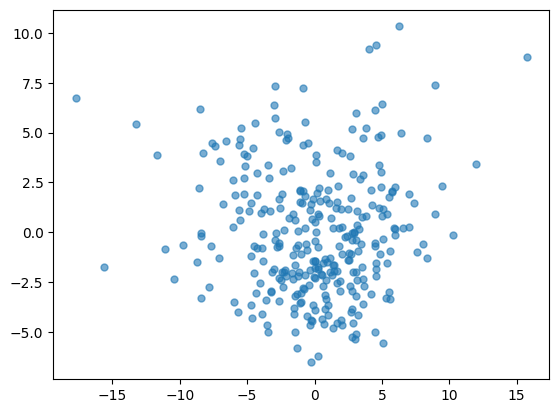

In [55]:
data_spec = data[data["position"] == "top"]

data_pure = data_spec[most_relevant_columns]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)

player_data = []
for player in tqdm(data_spec["playerid"].unique()):
    player_indexes = data_spec.loc[data_spec["playerid"] == player].index
    if len(player_indexes) <= 10:
        continue  

    mean = data_numeric.loc[player_indexes].mean().tolist()
    variance = data_numeric.loc[player_indexes].var().tolist()
    # add quantile information
    quantile = data_numeric.loc[player_indexes, data_numeric.columns[:5]].quantile([0.25, 0.5, 0.75]).values.T.flatten().tolist()

    player_data.append([player] + mean + variance + quantile)

player_data = pd.DataFrame(player_data, columns=["playerid"] + list(data_numeric.columns) + [f"{col}_var" for col in data_numeric.columns] + [f"{col}_{q}" for col in data_numeric.columns[:5] for q in [0.25, 0.5, 0.75]])

X = player_data.drop(columns=["playerid"]).to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

# plot pca 
pca = sklearn.decomposition.PCA(n_components=2).fit(X_normalized)
X_pca = pca.transform(X_normalized)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], s=25, alpha=0.6)
plt.show()


In [56]:
clustering = sklearn.cluster.KMeans(n_clusters=2).fit(X_normalized)
for i in range(2):
    print(f"Cluster {i}:")
    cluster_indices = np.where(clustering.labels_ == i)[0]
    print(len(cluster_indices))
    #with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    #    print(player_data.iloc[cluster_indices][player_data.columns[1:]].mean())
print("__")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    z = np.mean(player_data.iloc[np.where(clustering.labels_ == 0)[0]][player_data.columns[1:]], axis=0) - np.mean(player_data.iloc[np.where(clustering.labels_ == 1)[0]][player_data.columns[1:]], axis=0)
    print(z)


Cluster 0:
113
Cluster 1:
193
__
kills                          -8.929727e-01
deaths                          4.657569e-01
assists                        -4.771583e-01
damagetochampions              -3.416071e+03
dpm                            -9.869396e+01
damageshare                    -2.204880e-02
damagetakenperminute            2.499176e+01
damagemitigatedperminute        4.992267e+01
damagetotowers                 -1.490992e+03
wardsplaced                    -4.560072e-01
visionscore                    -2.609295e+00
totalgold                      -1.239503e+03
minionkills                    -1.975708e+01
monsterkills                   -2.725521e+00
xpat10                         -1.028051e+02
csat10                         -4.842956e+00
goldat10                       -1.241647e+02
xpat15                         -1.943621e+02
csat15                         -7.630209e+00
goldat15                       -2.461785e+02
xpat20                         -3.325407e+02
csat20                

While the PCA is not great, when we cluster the top laners into two clusters using Kmeans we do find that one of the clusters has less kills, more damage taken, less gold overall than the other cluster. We can print their their tank / figher champion usage:

In [57]:
for i in range(2):
    print(f"Cluster {i}:")
    cluster_indices = np.where(clustering.labels_ == i)[0]
    print(player_data.iloc[cluster_indices][["Tank"]].mean())
    print(player_data.iloc[cluster_indices][["Fighter"]].mean())

Cluster 0:
Tank    0.530144
dtype: float64
Fighter    0.826987
dtype: float64
Cluster 1:
Tank    0.406145
dtype: float64
Fighter    0.89545
dtype: float64


And we find that one of the clusters tends to play more tanky defensive champions than the other. 

## Clustering similar player performances
We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [58]:
X_hat = X_normalized


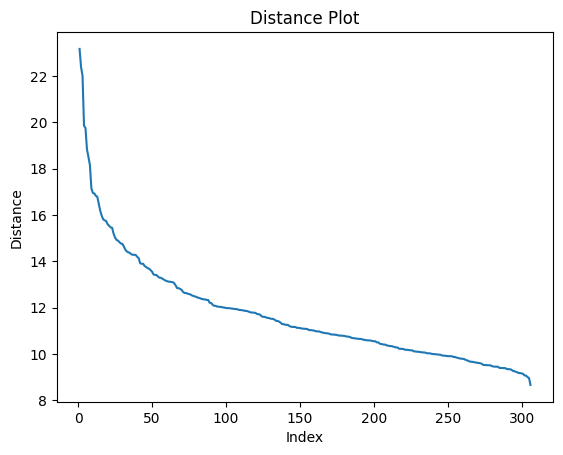

In [59]:
neighbors = 2*X_hat.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
distances, indices = nbrs.kneighbors(X_hat)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [60]:
density_cluster = sklearn.cluster.DBSCAN(eps=2.5, min_samples = neighbors).fit(X_hat)
labels = np.unique(density_cluster.labels_)
labels

array([-1], dtype=int64)

We see using this method we only get one cluster, which is not entirely surprising considering the very high dimensionality of the data which is causing min pts to be very large based on the heuristic. To try to alleviate this we cna use PCA to reduce dimensionality to hopefully improve the results.

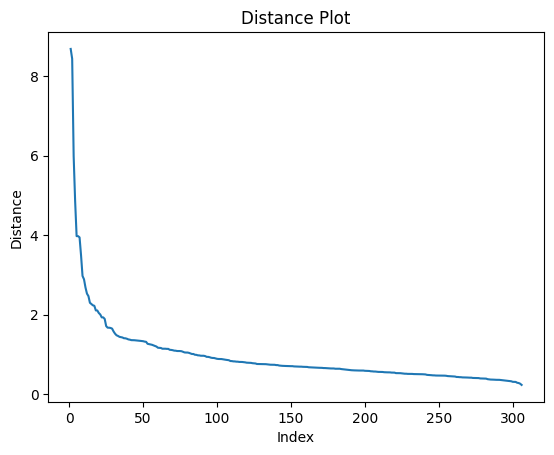

In [61]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 2*X_pca.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [62]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.3, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
unique_labels

array([-1,  0,  1,  2], dtype=int64)

Now we are seeing a few too many clusters due to the rule of thumb for min pts not really working well for this type of data, as we ideally want to group games fall into more broad clusters. So we will manually set min pts to 20.

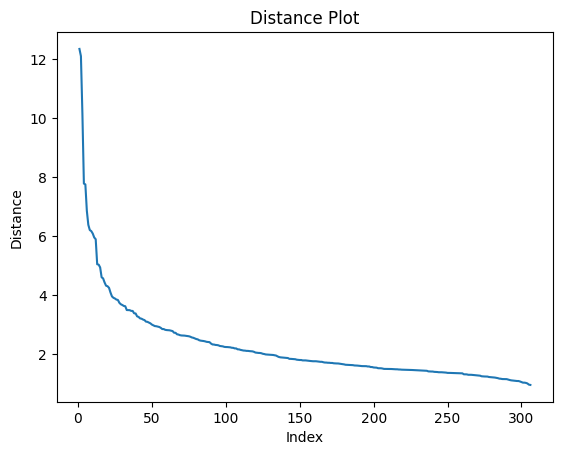

In [63]:
neighbors = 20
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [64]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.6, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1], dtype=int64)

In [65]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1], dtype=int64), array([306], dtype=int64))

We are not getting any clusters which is not ideal, we'll plot the data and see potentially why

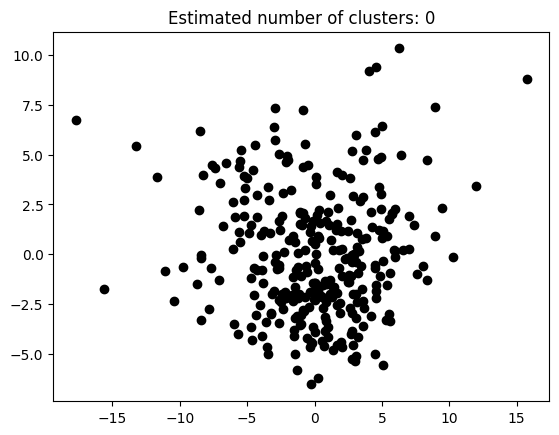

In [66]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

There is a potential cluster, which we may be able to find using by tweaking parameters yet we believe it would be more pertinent to instead try to look at clustering similar matches intstead using DBSCAN first.


# Clustering similar matches

We will combine the two team rows into one "match" row for looking at the data

In [67]:
cwd = Path('.')
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data: pd.DataFrame = pd.read_csv(data_path)
data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)
data.drop(data.columns[[0]], axis=1, inplace=True)

data = data.drop(data[data["position"] != "team"].index) 
# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.2
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

data_pure = data.drop(columns=["datacompleteness", "year", "playoffs", "date", "game", "patch", "participantid", "teamid"])


most_relevant_columns = ['gameid','side','gamelength','kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
data_pure = data[most_relevant_columns]
data_pure = data_pure.pivot(index=['gameid'],columns='side')
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)



C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\628570970.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


In [68]:


def create_distance_plot(X_hat, neighbors):
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
    distances, indices = nbrs.kneighbors(X_hat)
    distance_desc = sorted(distances[:,neighbors-1], reverse=True)
    plt.plot(
        range(1, len(distance_desc) + 1),
        distance_desc
    )

    plt.xlabel("Index")
    plt.ylabel("Distance")
    plt.title("Distance Plot")

    plt.show()
    

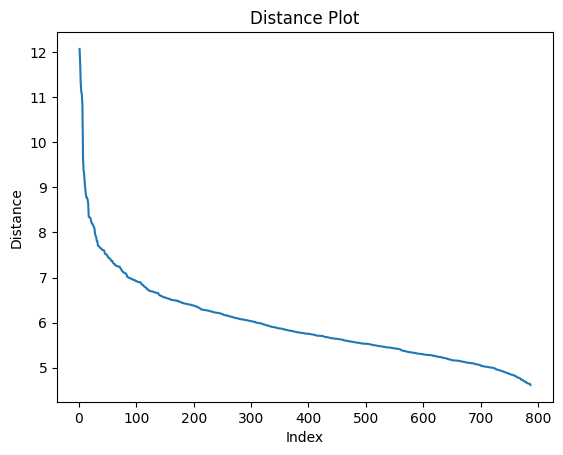

In [69]:
X_hat = X_normalized
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 30
create_distance_plot(X_hat,neighbors)

In [70]:
density_cluster = sklearn.cluster.DBSCAN(eps=7, min_samples = neighbors).fit(X_hat)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0], dtype=int64)

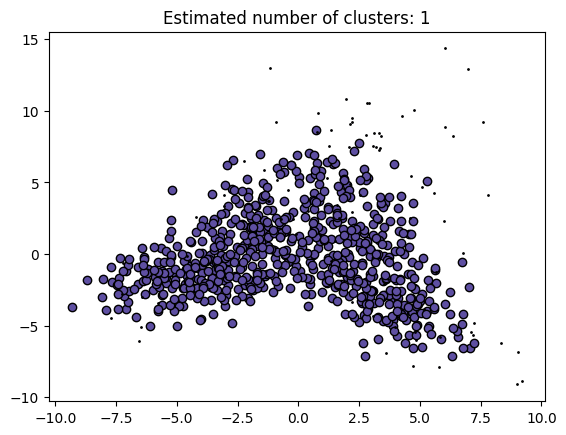

In [71]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=1,
        
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

While we are still only finding one cluster it does visually look more like there are two distinct clusters, so we are going to use a different method

We can try to use OPTICS instead since it is better suited for such high dimensional data

In [72]:
clust = OPTICS(min_samples=50, cluster_method='dbscan',max_eps=5.0)

clust.fit(X_normalized)

np.unique(clust.labels_)

array([-1,  0,  1])

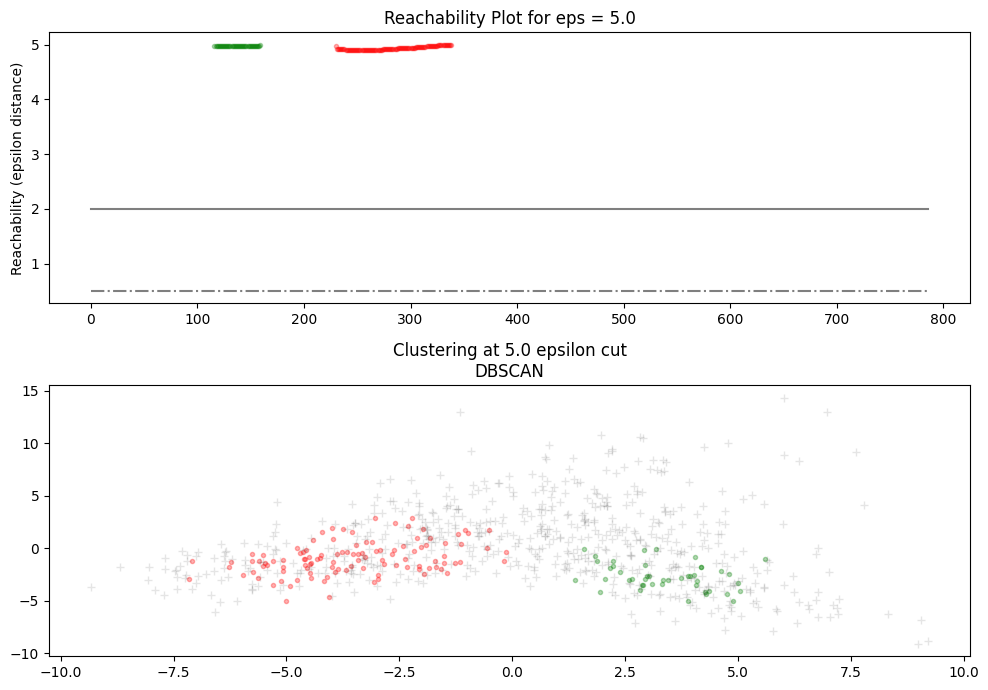

In [73]:
def create_optics_plot(X_hat,X_pca,clust,eps_val):
    space = np.arange(len(X_hat))
    reachability = clust.reachability_[clust.ordering_]
    labels = clust.labels_[clust.ordering_]

    plt.figure(figsize=(10, 7))
    G = gridspec.GridSpec(2, 3)
    ax1 = plt.subplot(G[0, :])
    ax2 = plt.subplot(G[1, :])


    # Reachability plot
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = space[labels == klass]
        Rk = reachability[labels == klass]
        ax1.plot(Xk, Rk, color, alpha=0.3)
    ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
    ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
    ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
    ax1.set_ylabel("Reachability (epsilon distance)")
    ax1.set_title("Reachability Plot for eps = " + str(eps_val))

    # OPTICS
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = X_pca[clust.labels_ == klass]
        ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
    ax2.plot(X_pca[clust.labels_ == -1, 0], X_pca[clust.labels_ == -1, 1], "k+", alpha=0.1)
    ax2.set_title("Clustering at " + str(eps_val) +" epsilon cut\nDBSCAN")


    plt.tight_layout()
    plt.show()
create_optics_plot(X_hat, X_pca, clust, eps_val= 5.0)

Now we are beginning to see 2 clusters, however they are not that far from eachother as seen in the reachability plot and they are quite susceptible to change with even small changes to epsillon,and a large portion of the points are not part of any cluster. So regardless of what we find these clusters do not appear to be very strong, however we now need to investigate the points in the clusters and see what type of matches these clusters are.

In [74]:
data_pure['cluster'] = clust.labels_

cluster_means = data_pure.groupby('cluster').mean()
cluster_means

gamelength                   kills                deaths             \
side            Blue          Red       Blue        Red       Blue        Red   
cluster                                                                         
-1       2010.908228  2010.908228  16.104430  15.830696  15.884494  16.153481   
 0       1785.688889  1785.688889   6.266667  18.733333  18.777778   6.311111   
 1       1809.236364  1809.236364  18.718182   6.918182   6.963636  18.736364   

           assists            damagetochampions                ...  \
side          Blue        Red              Blue           Red  ...   
cluster                                                        ...   
-1       38.061709  37.120253      92995.537975  92516.096519  ...   
 0       14.088889  45.244444      62656.644444  81036.000000  ...   
 1       45.709091  14.945455      83153.272727  62965.872727  ...   

             csat20                  goldat20                      xpat25  \
side           Blue         Red          Blue           Red          Blue   
cluster                                                                     
-1       689.930380  693.905063  34437.324367  34235.735759  52989.651899   
 0       696.933333  724.822222  32659.133333  35324.688889  51179.822222   
 1       719.363636  697.654545  35743.900000  32737.990909  55408.554545   

                           csat25                  goldat25                
side              Red        Blue         Red          Blue           Red  
cluster                                                                    
-1       53143.028481  842.713608  847.314873  43677.993671  43424.495253  
 0       56338.600000  848.800000  896.022222  40568.511111  46088.311111  
 1       51242.436364  880.963636  850.527273  45861.063636  40851.845455  

[3 rows x 52 columns]

Appears to be finding games where Red did better than blue vs blue better than red, which is not really that interesting. So we should focus on splitting the data into games where blue won vs games where red won, to try and find something more interesting.

In [75]:
data_pure = data[most_relevant_columns+["result"]]
data_pure = data_pure.pivot(index=['gameid'],columns='side')
red_wins  = data_pure.loc[data_pure[('result', 'Red')] == 1]
blue_wins = data_pure.loc[data_pure[('result', 'Blue')] == 1]
red_wins = red_wins.drop(columns="result")
blue_wins = blue_wins.drop(columns="result")

In [76]:
def normalize_data(data):
    data_numeric = pd.get_dummies(data, dtype=float)
    X = data_numeric.to_numpy()
    X.shape

    X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

    # calculate the zero-centered data matrix and the covariance matrix
    X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
    X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

    # calculate the standard score normalized matrix and the correlation matrix
    X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
    X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)
    return(X_normalized,X_cov,X_cor)

red_normalized, red_cov, red_cor = normalize_data(red_wins)
blue_normalized, blue_cov, blue_cor = normalize_data(blue_wins)


In [77]:
X_hat = red_normalized
clust = OPTICS(min_samples=20, cluster_method='dbscan')

clust.fit(X_hat)

np.unique(clust.labels_)

pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

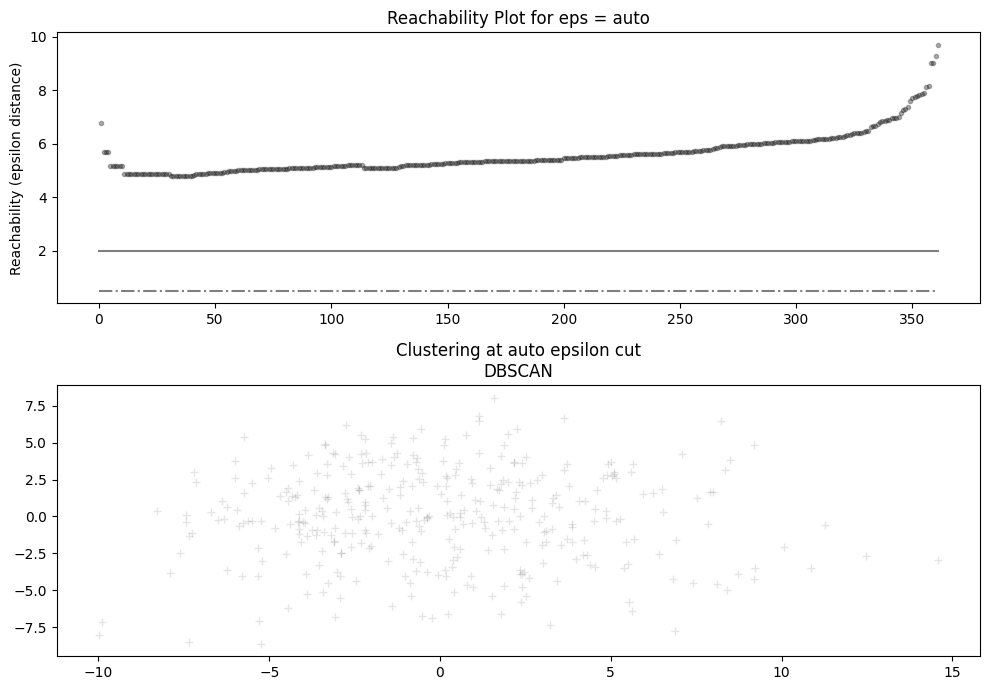

In [78]:
create_optics_plot(X_hat, X_pca, clust, eps_val = "auto")

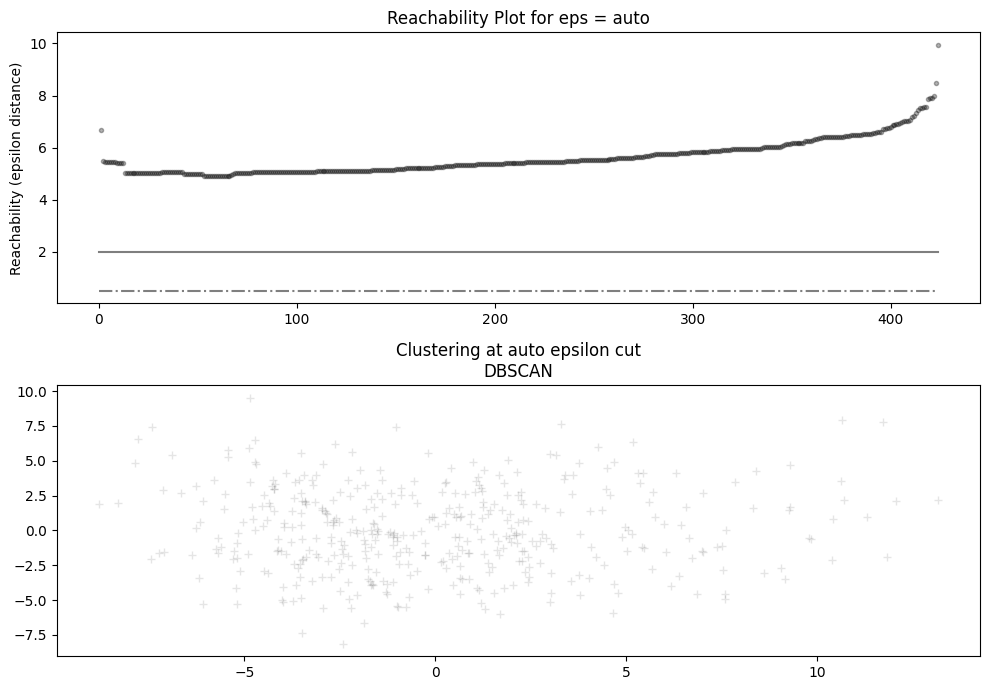

In [79]:
X_hat = blue_normalized
clust = OPTICS(min_samples=20, cluster_method='dbscan')

clust.fit(X_hat)

np.unique(clust.labels_)

pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

create_optics_plot(X_hat, X_pca, clust, eps_val="auto")

Now we are back to struggling to find any clear dense regions that suggest similar matches for both red aand blue winning. This can of course suggest that using our parameters that every game was sufficiently different from eachother, but we are also making our data more and more sparse and therefore reducing the number of points that could create these dense areas. And we will also try to look into this with the full data.

## Team clustering

In [80]:
from utils.constants import most_relevant_columns, pos_order
from utils.transform import champion_class_transform

In [ ]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path) # ADdded due to rereading in the middle section (Temp solution)
#data = data.drop(data[data["position"] == "team"].index) 

# drop columns with more than a given percentage of missing values


C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\3030158950.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


In [92]:
# Group by game id, and then for each team, join the rows together, so that we have one row per team per game, with all the stats for that team in that game. Keep the kills deaths and assists. Make sure to join the team members in the other of position (top, jgl, mid, bot, sup). Append the colums, so you get one big row per team.
df = data.copy()
# Remove position "team"
df = df[df['position'] != 'team']
df['position'] = pd.Categorical(df['position'], categories=pos_order, ordered=True)
champion_class_transform(df)

df = df.sort_values(by=['gameid', 'teamname', 'position'])
#selected_columns = ['kills', 'deaths', 'assists']
selected_columns = most_relevant_columns
selected_columns = [col for col in selected_columns if col != 'champion']
team_df = df.pivot(index=['gameid', 'teamname', 'gamelength'], columns='position', values=selected_columns)

team_df.columns = [f'{val}_{pos}' for val, pos in team_df.columns]

team_df = team_df.reset_index()

results = data[data['position'] == 'team'][['gameid', 'teamname', 'result']]
team_df = team_df.merge(results, on=['gameid', 'teamname'])
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
0,11715-11715_game_1,Oh My God,2123,1.0,2.0,0.0,2.0,0.0,2.0,4.0,...,NaN,NaN,NaN,NaN,2123.0,2123.0,2123.0,2123.0,2123.0,0
1,11715-11715_game_1,Weibo Gaming,2123,4.0,4.0,5.0,3.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,2123.0,2123.0,2123.0,2123.0,2123.0,1
2,11715-11715_game_2,Oh My God,1952,6.0,1.0,4.0,0.0,0.0,1.0,6.0,...,NaN,NaN,NaN,NaN,1952.0,1952.0,1952.0,1952.0,1952.0,0
3,11715-11715_game_2,Weibo Gaming,1952,5.0,6.0,1.0,4.0,2.0,3.0,2.0,...,NaN,NaN,NaN,NaN,1952.0,1952.0,1952.0,1952.0,1952.0,1
4,11715-11715_game_3,Oh My God,2014,1.0,6.0,6.0,5.0,0.0,4.0,6.0,...,NaN,NaN,NaN,NaN,2014.0,2014.0,2014.0,2014.0,2014.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,8253.0,9899.0,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,9398.0,12404.0,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,8313.0,9433.0,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,8704.0,8827.0,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0


In [94]:
duplicate_mask = df.duplicated(subset=['gameid', 'teamname', 'position'], keep=False)
problem_rows = df[duplicate_mask].sort_values(['gameid', 'teamname', 'position'])
print(f"Found {len(problem_rows)}/{len(df)} duplicate rows.")

Found 0/100530 duplicate rows.


Text(0.5, 1.0, 'percentage of missing values by column')

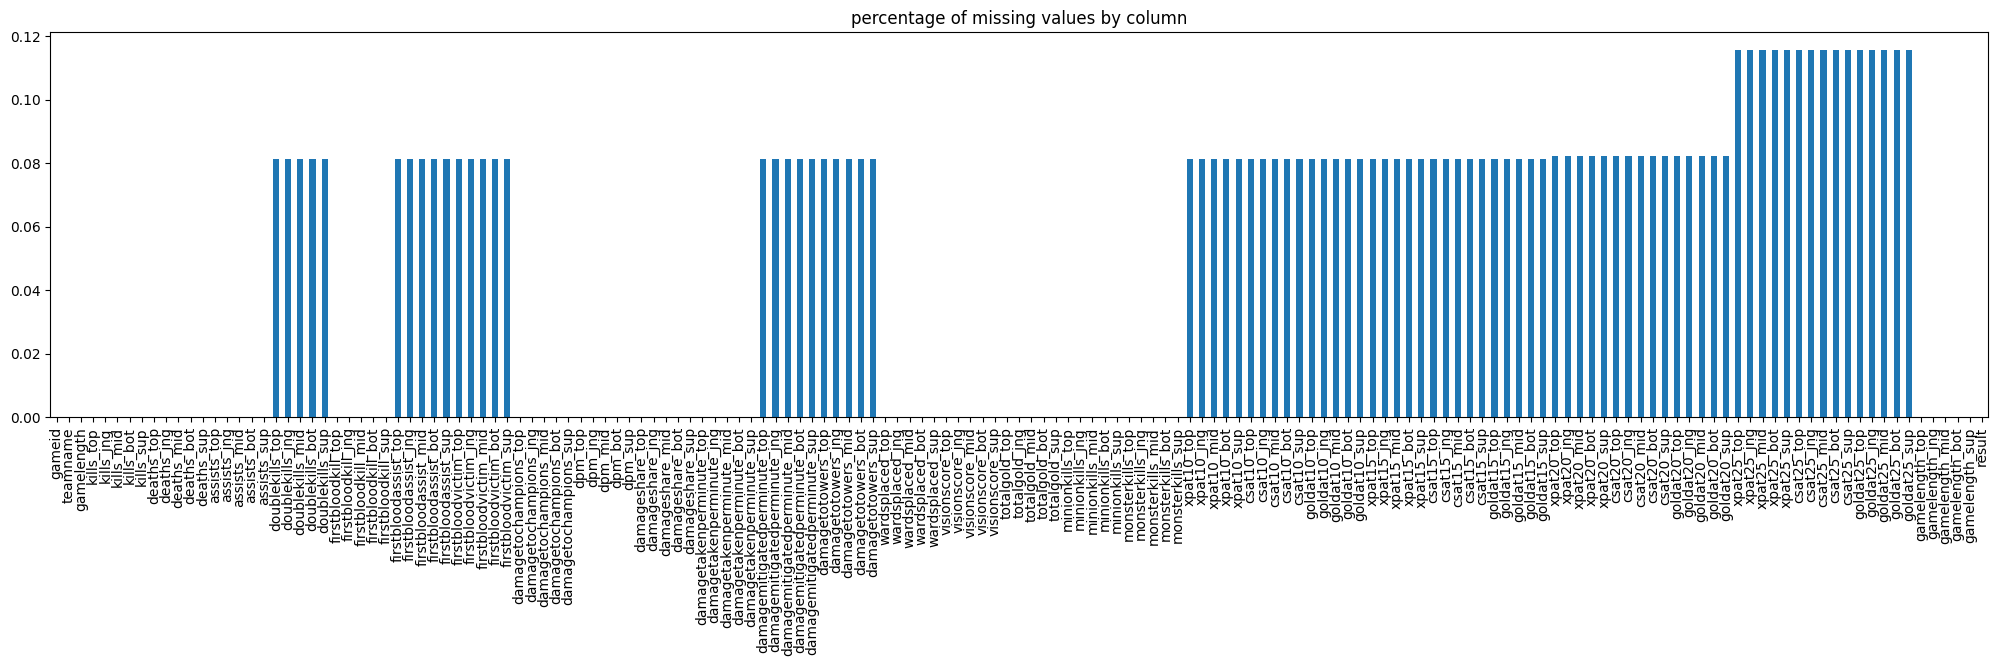

In [95]:
team_df.isnull().mean().plot(kind='bar', figsize=(25, 5))
plt.title('percentage of missing values by column')

Remaining data: 17784/20106


<AxesSubplot: >

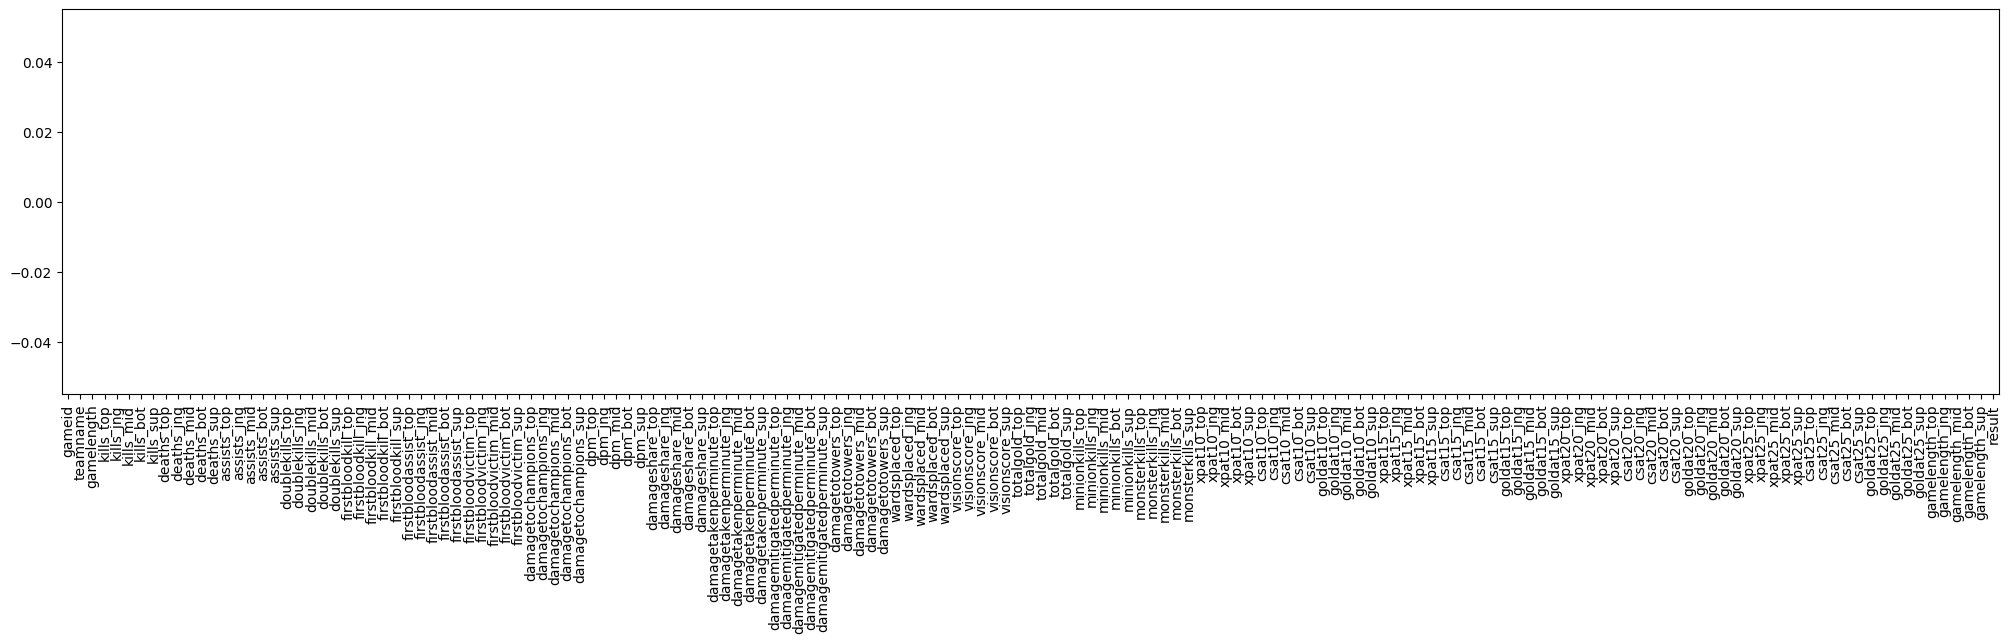

In [96]:
from utils.transform import smart_drop_na

full_length = len(team_df)
team_df = smart_drop_na(team_df)

# Remaining data:
print(f"Remaining data: {len(team_df)}/{full_length}")
team_df.isnull().mean().plot(kind='bar', figsize=(25, 5))

In [97]:
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
1634,LOLTMNT01_189225,Chiefs Esports Club,1522,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,7595.0,8034.0,8645.0,5262.0,1522.0,1522.0,1522.0,1522.0,1522.0,0
1635,LOLTMNT01_189225,PSG Talon,1522,1.0,4.0,6.0,2.0,0.0,0.0,0.0,...,9974.0,11030.0,10678.0,6579.0,1522.0,1522.0,1522.0,1522.0,1522.0,1
1636,LOLTMNT01_189281,GAM Esports,2266,1.0,4.0,1.0,0.0,1.0,5.0,3.0,...,10167.0,8507.0,9006.0,6325.0,2266.0,2266.0,2266.0,2266.0,2266.0,0
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,2.0,2.0,3.0,9.0,2.0,2.0,2.0,...,8301.0,8872.0,11944.0,6137.0,2266.0,2266.0,2266.0,2266.0,2266.0,1
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,1.0,4.0,1.0,6.0,0.0,0.0,3.0,...,9327.0,8294.0,11085.0,6016.0,1565.0,1565.0,1565.0,1565.0,1565.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,8253.0,9899.0,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,9398.0,12404.0,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,8313.0,9433.0,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,8704.0,8827.0,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0


In [98]:
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(team_df.drop(columns=['gameid', 'teamname', "result"]))

kmeans = KMeans(n_clusters=4, n_init=10)
team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

In [99]:
team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result,cluster_label
1634,LOLTMNT01_189225,Chiefs Esports Club,1522,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,8034.0,8645.0,5262.0,1522.0,1522.0,1522.0,1522.0,1522.0,0,1
1635,LOLTMNT01_189225,PSG Talon,1522,1.0,4.0,6.0,2.0,0.0,0.0,0.0,...,11030.0,10678.0,6579.0,1522.0,1522.0,1522.0,1522.0,1522.0,1,0
1636,LOLTMNT01_189281,GAM Esports,2266,1.0,4.0,1.0,0.0,1.0,5.0,3.0,...,8507.0,9006.0,6325.0,2266.0,2266.0,2266.0,2266.0,2266.0,0,3
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,2.0,2.0,3.0,9.0,2.0,2.0,2.0,...,8872.0,11944.0,6137.0,2266.0,2266.0,2266.0,2266.0,2266.0,1,2
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,1.0,4.0,1.0,6.0,0.0,0.0,3.0,...,8294.0,11085.0,6016.0,1565.0,1565.0,1565.0,1565.0,1565.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20101,LOLTMNT06_96972,Solary,1847,2.0,3.0,3.0,4.0,2.0,6.0,3.0,...,9899.0,10251.0,6114.0,1847.0,1847.0,1847.0,1847.0,1847.0,0,1
20102,LOLTMNT06_96989,BK ROG Esports,1954,0.0,1.0,7.0,7.0,1.0,1.0,3.0,...,12404.0,10630.0,6021.0,1954.0,1954.0,1954.0,1954.0,1954.0,1,3
20103,LOLTMNT06_96989,Galions,1954,0.0,3.0,3.0,4.0,0.0,2.0,4.0,...,9433.0,10146.0,5317.0,1954.0,1954.0,1954.0,1954.0,1954.0,0,1
20104,LOLTMNT06_96993,Joblife,1711,0.0,2.0,0.0,6.0,1.0,5.0,4.0,...,8827.0,11422.0,6316.0,1711.0,1711.0,1711.0,1711.0,1711.0,0,1


In [100]:
from utils.visualize import cluster_summary

In [101]:
cluster_sum = cluster_summary(team_df) 
cluster_sum

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,csat10_bot,csat10_jng,csat10_mid,csat10_sup,csat10_top,...,xpat20_bot,xpat20_jng,xpat20_mid,xpat20_sup,xpat20_top,xpat25_bot,xpat25_jng,xpat25_mid,xpat25_sup,xpat25_top
cluster_label,,,,,,,,,,,,,,,,,,,,,
0,1.408542,1.378538,1.414799,1.443365,1.391407,1.007399,1.016189,1.000292,0.959657,1.010804,...,1.045428,1.069590,1.030808,1.063674,1.030074,1.079966,1.115243,1.061105,1.122721,1.062496
1,0.504017,0.506125,0.476088,0.496139,0.453741,0.970579,0.964945,0.970285,1.000183,0.963996,...,0.958374,0.945803,0.965041,0.982803,0.967208,0.932991,0.916497,0.943678,0.952380,0.942460
2,1.410482,1.413597,1.432957,1.381707,1.507598,1.002823,1.002829,1.001591,1.015915,0.995505,...,0.999576,0.996645,0.995979,0.985872,0.994617,0.997878,0.992099,0.993599,0.975899,0.992343
3,0.913808,0.937025,0.924523,0.907100,0.926164,1.022592,1.020535,1.030062,1.027233,1.030648,...,1.002787,0.995769,1.011121,0.968451,1.010295,0.999113,0.987778,1.007462,0.952611,1.008206


In [102]:
# For each cluster, calculate the win rate
win_rates = team_df.groupby('cluster_label')['result'].mean()
win_rates

cluster_label
0    0.958808
1    0.017965
2    0.605925
3    0.529330
Name: result, dtype: float64

In [ ]:
losing_team_df = team_df[team_df['result'] == 0]
winning_team_df = team_df[team_df['result'] == 1]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(winning_team_df.drop(columns=['gameid', 'teamname', "result"])) # Removed droppoing cluter label as its not there

kmeans = KMeans(n_clusters=4, n_init=10)
winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

cluster_sum_winning = cluster_summary(winning_team_df)
cluster_sum_winning.filter(regex='^(totalgold)_')

C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\3163696615.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)


,totalgold_bot,totalgold_jng,totalgold_mid,totalgold_sup,totalgold_top
cluster_label,,,,,
0,0.982619,0.961270,0.997099,0.968661,1.012625
1,0.872661,0.952263,0.899312,0.910448,0.912849
2,0.992943,0.955264,0.955933,0.998652,0.921695
3,1.251735,1.199874,1.225460,1.206015,1.216064


In [104]:
cluster_sum_winning.filter(regex='^(gamelength)')

,gamelength,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top
cluster_label,,,,,,
0,1.004744,1.004744,1.004744,1.004744,1.004744,1.004744
1,0.869136,0.869136,0.869136,0.869136,0.869136,0.869136
2,0.955640,0.955640,0.955640,0.955640,0.955640,0.955640
3,1.263041,1.263041,1.263041,1.263041,1.263041,1.263041


In [105]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(winning_team_df.drop(columns=['gameid', 'teamname', "result"]))
iso = IsolationForest(contamination=0.01)
winning_team_df['is_outlier'] = iso.fit_predict(scaled_data)
outliers = winning_team_df[winning_team_df['is_outlier'] == -1]
print(f"Detected {len(outliers)} unusual games.")

Detected 89 unusual games.


C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\406403066.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['is_outlier'] = iso.fit_predict(scaled_data)


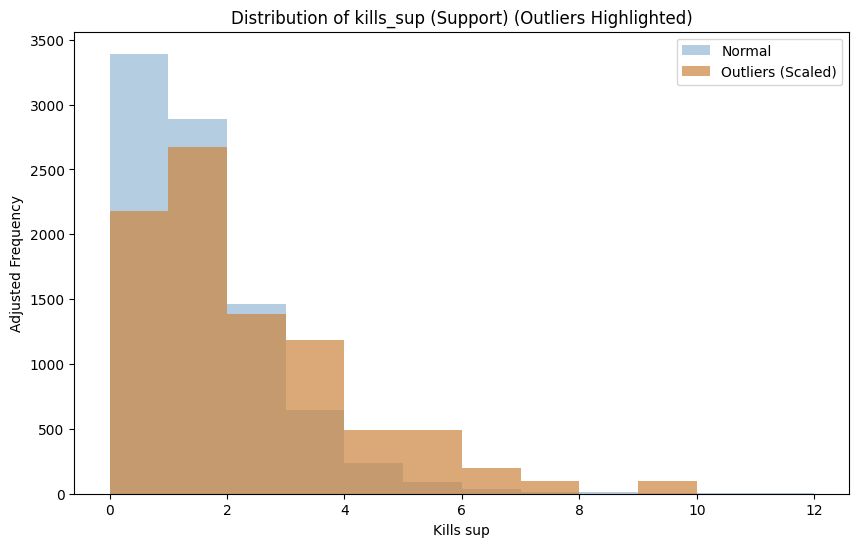

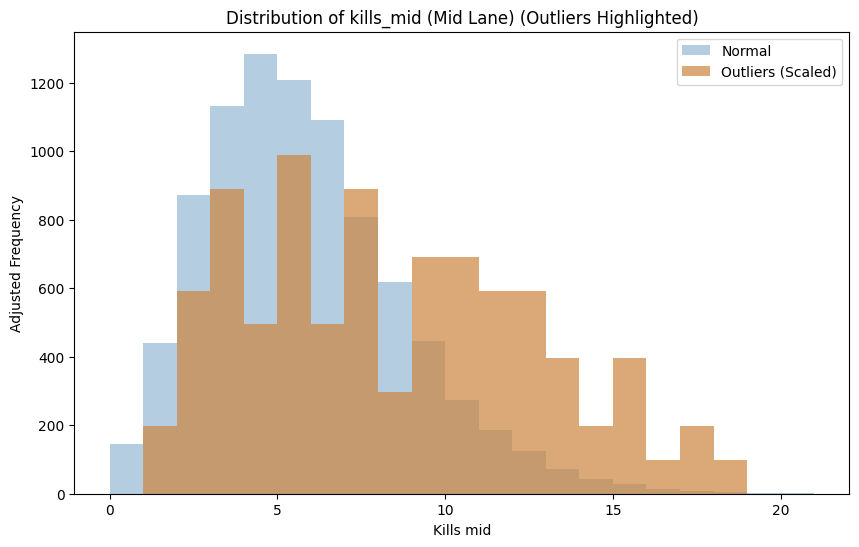

In [106]:
from utils.visualize import plot_outlier_distribution

plot_outlier_distribution(winning_team_df, 'kills_sup', title_suffix="(Support)")
plot_outlier_distribution(winning_team_df, 'kills_mid', title_suffix="(Mid Lane)")

### Example of learning bias for kills_mid against the gamelength

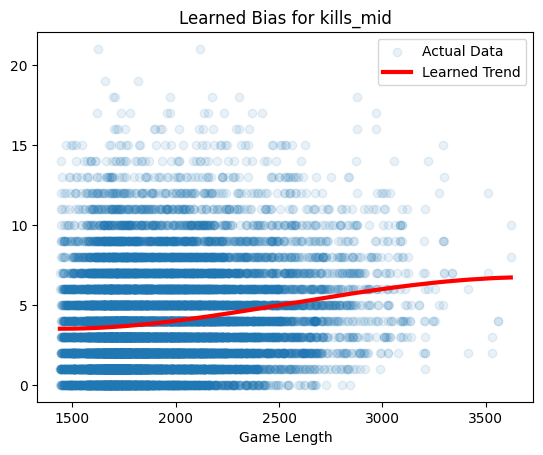

In [107]:
from utils.transform import simple_scale_model
# 1. Setup the model: Splines + Ridge Regression
# 'n_knots' determines how "wiggly" the curve can be. 5-10 is usually plenty.

target_col = 'kills_mid' 
X = team_df[['gamelength']].sort_values(by='gamelength')
y = team_df.loc[X.index, target_col]

simple_scale_model.fit(X, y)
curve = simple_scale_model.predict(X)

plt.scatter(X, y, alpha=0.1, label='Actual Data')
plt.plot(X, curve, color='red', linewidth=3, label='Learned Trend')
plt.title(f'Learned Bias for {target_col}')
plt.xlabel('Game Length')
plt.legend()
plt.show()

In [108]:
from utils.transform import scale_df
lengthscaled_winning_team_df = scale_df(winning_team_df.drop(columns=['cluster_label', 'is_outlier']))

c:\Users\dwarf\OneDrive\Skrivebord\Datamining_project\Datamining_project\utils\transform.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_residuals[col] = df[col] - model.predict(df[['gamelength']])
c:\Users\dwarf\OneDrive\Skrivebord\Datamining_project\Datamining_project\utils\transform.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_residuals[col] = df[col] - model.predict(df[['gamelength']])
c:\Users\dwarf\OneDrive\Skrivebord\Datamining_project\Datamining_project\utils\transform.py:86: PerformanceWarning: DataFr

In [109]:
lengthscaled_winning_team_df

,gameid,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
1635,LOLTMNT01_189225,PSG Talon,1522,-3.331673,-1.239890,0.607745,-4.843468,-1.261461,-1.513722,-1.254015,...,-437.469236,-73.076281,-1065.087986,-351.589086,1522.0,1522.0,1522.0,1522.0,1522.0,1
1637,LOLTMNT01_189281,MGN Vikings Esports,2266,-2.262855,-2.184300,-2.388630,1.779860,0.946525,-0.906902,-0.906211,...,-593.449288,-771.534995,1875.086256,209.478396,2266.0,2266.0,2266.0,2266.0,2266.0,1
1640,LOLTMNT01_189291,CTBC Flying Oyster,1565,-3.285924,-1.111040,-4.349314,-0.768951,-1.230827,-1.554207,1.677290,...,-919.882570,-2656.183281,-466.393034,-795.318200,1565.0,1565.0,1565.0,1565.0,1565.0,1
1642,LOLTMNT01_189329,Gamespace Mediterranean College Esports,1779,-1.143838,-2.606382,0.779466,-2.626189,-0.120376,0.143502,0.264716,...,-659.661246,-176.576026,904.957336,651.200000,1779.0,1779.0,1779.0,1779.0,1779.0,1
1644,LOLTMNT01_189338,Actions Per Minute,2123,-3.173781,-1.216703,-2.279952,3.032955,-0.054785,-0.574684,2.448697,...,-557.714869,-932.328240,232.714004,-448.910117,2123.0,2123.0,2123.0,2123.0,2123.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20097,LOLTMNT06_96870,Karmine Corp Blue Stars,2792,-0.850474,-0.546867,-2.111958,6.944303,-1.079436,0.050344,-1.013317,...,-1288.161345,-31.028236,-904.726679,-345.322459,2792.0,2792.0,2792.0,2792.0,2792.0,1
20098,LOLTMNT06_96906,IziDream,2169,-0.198134,-4.198810,0.690017,0.955272,-1.053223,0.318802,-0.665881,...,-1423.859831,716.045199,4.884127,384.048985,2169.0,2169.0,2169.0,2169.0,2169.0,1
20100,LOLTMNT06_96972,BK ROG Esports,1847,4.873648,-1.490668,-2.207605,-0.648158,-1.098054,2.018759,2.114042,...,-1401.553432,-1373.045233,613.857655,-157.225273,1847.0,1847.0,1847.0,1847.0,1847.0,1
20102,LOLTMNT06_96989,BK ROG Esports,1954,-4.123297,-3.348698,1.787299,0.265775,-0.073215,-1.197992,0.863767,...,163.207507,2419.139600,212.158502,-100.482291,1954.0,1954.0,1954.0,1954.0,1954.0,1


In [110]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(lengthscaled_winning_team_df.drop(columns=['gameid', 'teamname', "result", "gamelength"]))

kmeans = KMeans(n_clusters=2, n_init=10)
winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)

C:\Users\dwarf\AppData\Local\Temp\ipykernel_17436\1470355347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winning_team_df['cluster_label'] = kmeans.fit_predict(scaled_data)


In [111]:
prof_sum_winning = cluster_summary(winning_team_df, cluster_col='cluster_label')
#prof_sum_winning.filter(regex='^(totalgold)_')
prof_sum_winning.filter(regex='^(kills)_')

,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,
0,1.193064,1.303555,1.156719,1.356737,1.074194
1,0.861522,0.782271,0.887591,0.744125,0.946783


In [112]:
prof_sum_winning.filter(regex='^(gamelength)$')

,gamelength
cluster_label,
0,0.997682
1,1.001662


In [113]:
# Number of games in each cluster
winning_team_df['cluster_label'].value_counts()

cluster_label
1    5178
0    3714
Name: count, dtype: int64

In [114]:
df_team_profiles = winning_team_df.drop(columns=['gameid'])
df_team_profiles = df_team_profiles.groupby('teamname').mean().reset_index()
df_team_profiles

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_team_profiles.drop(columns=['teamname', "result", "gamelength", "cluster_label"]))

kmeans = KMeans(n_clusters=4, n_init=10)
df_team_profiles['cluster_label'] = kmeans.fit_predict(scaled_data)
cluster_summary(df_team_profiles, cluster_col='cluster_label').filter(regex='^(kills|deaths|assists|gamelength)_')

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,deaths_bot,deaths_jng,deaths_mid,deaths_sup,deaths_top,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,,,,,,,,,,,,,,,,
0,1.118620,1.128812,1.092905,1.163906,1.222815,1.465681,1.451440,1.438542,1.285482,1.344020,1.155406,1.155406,1.155406,1.155406,1.155406,1.324043,0.995610,1.144758,1.019930,0.965137
1,1.100571,1.025920,1.096795,1.071714,1.049652,1.243442,1.039904,1.229761,1.154092,1.189670,0.957847,0.957847,0.957847,0.957847,0.957847,1.000665,1.303310,1.051021,1.248050,1.198817
2,0.975095,1.014859,0.971303,1.009103,0.970900,0.943318,0.969332,0.933183,0.951692,1.005062,0.952617,0.952617,0.952617,0.952617,0.952617,1.060589,0.952326,1.043380,1.094487,0.941541
3,0.946040,0.951946,0.955529,0.928185,0.947467,0.828211,0.902583,0.846011,0.900695,0.840946,1.012221,1.012221,1.012221,1.012221,1.012221,0.892799,0.900076,0.920774,0.833639,0.957699


In [115]:
df_team_profiles['cluster_label'].value_counts()

cluster_label
3    183
2    109
1     78
0     40
Name: count, dtype: int64

In [116]:
df_team_profiles = lengthscaled_winning_team_df.drop(columns=['gameid'])
df_team_profiles = df_team_profiles.groupby('teamname').mean().reset_index()
df_team_profiles

,teamname,gamelength,kills_top,kills_jng,kills_mid,kills_bot,kills_sup,deaths_top,deaths_jng,deaths_mid,...,goldat25_jng,goldat25_mid,goldat25_bot,goldat25_sup,gamelength_top,gamelength_jng,gamelength_mid,gamelength_bot,gamelength_sup,result
0,100 Thieves,2043.634146,-0.402599,-0.352557,0.468055,-0.610244,-0.178746,0.097721,0.102546,-0.358760,...,-124.763305,166.901989,-198.433973,-170.818076,2043.634146,2043.634146,2043.634146,2043.634146,2043.634146,1.0
1,3BL Esports,1922.000000,1.878804,-0.386180,2.791995,-1.702556,-0.079428,-0.130902,-2.059974,5.062371,...,-69.822838,191.020380,-1545.478409,-662.907296,1922.000000,1922.000000,1922.000000,1922.000000,1922.000000,1.0
2,5M Esports,2421.000000,-1.399840,1.779060,-1.554421,3.489659,0.939637,-0.258597,-0.277159,3.054426,...,742.424800,-885.025586,255.338082,-79.055349,2421.000000,2421.000000,2421.000000,2421.000000,2421.000000,1.0
3,7REX,2225.600000,-0.331168,0.839841,-0.468668,0.615641,-0.873258,-0.992301,-1.372363,-1.736623,...,303.597727,144.974945,160.867817,14.186836,2225.600000,2225.600000,2225.600000,2225.600000,2225.600000,1.0
4,A One Man Army,1997.777778,-1.165241,0.763104,0.120515,-0.844462,0.016025,0.011675,0.193133,0.843450,...,910.779559,141.536006,-259.294491,192.377195,1997.777778,1997.777778,1997.777778,1997.777778,1997.777778,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,mCon esports,1982.190476,0.038050,1.305171,1.361439,-1.264574,0.060342,0.259427,-0.278198,-0.306424,...,281.245844,182.455941,-523.814534,-42.567860,1982.190476,1982.190476,1982.190476,1982.190476,1982.190476,1.0
406,paiN Gaming,2034.406250,-0.318470,-0.948943,-1.299246,-0.602444,-0.120494,-0.654311,-1.156242,-0.269119,...,-363.522985,-398.131324,-64.574171,-247.775754,2034.406250,2034.406250,2034.406250,2034.406250,2034.406250,1.0
407,regnum4games,1812.000000,-4.133786,1.452326,-2.212648,0.366647,1.891140,-1.915603,-0.807458,0.266196,...,220.953909,-1710.965025,1393.883594,-33.275798,1812.000000,1812.000000,1812.000000,1812.000000,1812.000000,1.0
408,wangting,1886.916667,1.996635,2.709969,1.364844,0.498569,0.544973,1.174027,0.654878,1.013515,...,966.260153,85.400541,198.288355,438.955661,1886.916667,1886.916667,1886.916667,1886.916667,1886.916667,1.0


In [118]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_team_profiles.drop(columns=['teamname', "result", "gamelength"]))

kmeans = KMeans(n_clusters=4, n_init=10)
df_team_profiles['cluster_label'] = kmeans.fit_predict(scaled_data)
cluster_summary(df_team_profiles, cluster_col='cluster_label').filter(regex='^(kills|deaths|assists|gamelength)_')

,assists_bot,assists_jng,assists_mid,assists_sup,assists_top,deaths_bot,deaths_jng,deaths_mid,deaths_sup,deaths_top,gamelength_bot,gamelength_jng,gamelength_mid,gamelength_sup,gamelength_top,kills_bot,kills_jng,kills_mid,kills_sup,kills_top
cluster_label,,,,,,,,,,,,,,,,,,,,
0,-0.552654,-0.624505,-0.334103,-0.597918,-0.808221,-2.048402,-1.210455,-1.308360,-1.892183,-1.891693,1.003626,1.003626,1.003626,1.003626,1.003626,-1.211195,-1.331672,-0.489567,-1.050548,-0.377080
1,4.894555,2.328608,4.297847,3.337406,3.576084,5.222727,4.770273,3.779878,5.981784,4.723098,0.980568,0.980568,0.980568,0.980568,0.980568,1.858341,7.417543,3.279021,2.715916,6.283917
2,0.079446,2.579556,0.178723,1.743481,1.550502,2.307273,1.269333,1.576943,0.835469,1.984674,1.014561,1.014561,1.014561,1.014561,1.014561,4.405463,-1.351598,1.975589,2.649907,-3.422585
3,-4.261890,14.685232,-0.825419,2.748669,14.573664,16.328064,7.878833,40.584748,24.443593,33.714369,0.995536,0.995536,0.995536,0.995536,0.995536,14.493532,2.982762,-9.826144,27.650708,43.453779


In [120]:
df_team_profiles['cluster_label'].value_counts()

cluster_label
0    205
1    108
2     94
3      3
Name: count, dtype: int64